<a href="https://colab.research.google.com/github/alifiaindahbalkis-u/datasains/blob/main/SAINS_DATA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**ANALISIS PERGERAKAN SAHAM DAN KINERJA TOP TECH COMPANIES DI CAPITAL MARKET**

#**Business Understanding**
Permasalahan utama yang diangkat pada proyek ini adalah tingginya kompleksitas dan volatilitas pergerakan harga saham perusahaan-perusahaan raksasa di sektor teknologi (Top Tech Companies) di pasar modal. Sektor teknologi memiliki dinamika yang sangat reaktif terhadap sentimen pasar, yang tercermin dari fluktuasi metrik harga harian (Open, High, Low, Close) dan likuiditas volume transaksi. Menganalisis metrik historis ini secara manual untuk mengidentifikasi pola tren jangka panjang dan mengukur tingkat risiko investasi sangatlah tidak efisien dan rentan terhadap bias persepsi.

Oleh karena itu, diperlukan suatu pendekatan komputasi berbasis data untuk membantu investor dan pemangku kepentingan dalam memetakan perilaku pasar. Hal ini diatasi dengan mengimplementasikan algoritma Supervised Machine Learning melalui pendekatan klasifikasi dan regresi untuk memodelkan data historis. Dengan memanfaatkan model prediktif dan visualisasi tingkat lanjut (seperti analisis Rolling Volatility), kita dapat mengolah dataset pasar modal menjadi wawasan komparatif yang objektif. Insight ini mencakup proyeksi arah tren dan harga di masa depan, pengukuran tingkat risiko aset, serta analisis likuiditas transaksi, yang pada akhirnya dapat dijadikan dasar pengambilan keputusan investasi yang lebih terukur di industri teknologi.

#**Data Understanding**
Tahap Data Understanding berfokus pada pengenalan dan pemahaman terhadap struktur, karakteristik, dan kualitas data sebelum dilakukan pemodelan analitik. Dataset yang digunakan dalam analisis ini memuat data riwayat pergerakan harga saham harian dari perusahaan-perusahaan besar, khususnya raksasa teknologi.

**Sumber dan Dimensi Data**

1.   Dataset ini memiliki skala yang cukup besar, terdiri dari 25.486 baris data dan 8 kolom (variabel).
2.   Rentang Waktu: Data yang terekam mencakup periode perdagangan dari 2 Januari 2015 hingga 29 Agustus 2024.






##**Import Library**


In [ ]:
import pandas as pd #menganalisa atau membaca dataset
import numpy as np #manipulasi numerik, array
import matplotlib.pyplot as plt #membuat visualisasi data, seperti grafik, diagram...
import seaborn as sns #kalo ada plt pasti ada sns
from google.colab import drive
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pickle
from matplotlib.ticker import PercentFormatter



In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Gunakan pd.read_csv untuk membaca file
path = '/content/drive/MyDrive/SAINS DATA/SAINS DATA KELOMPOK 11/DATASET/Dataset 10 Perusahaan Besar dibidang Teknologi.csv'
df = pd.read_csv(path)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##**Load Dataset**

In [ ]:
df

,Date,Ticker,Open,High,Low,Close,Adj Close,Volume
0,2015-01-02,AAPL,27.847500,27.860001,26.837500,27.332500,24.373959,212818400
1,2015-01-05,AAPL,27.072500,27.162500,26.352501,26.562500,23.687313,257142000
2,2015-01-06,AAPL,26.635000,26.857500,26.157499,26.565001,23.689535,263188400
3,2015-01-07,AAPL,26.799999,27.049999,26.674999,26.937500,24.021711,160423600
4,2015-01-08,AAPL,27.307501,28.037500,27.174999,27.972500,24.944679,237458000
...,...,...,...,...,...,...,...,...
25481,2024-08-23,LLY,955.440002,960.500000,943.109985,952.739990,952.739990,2063300
25482,2024-08-26,LLY,949.200012,955.000000,942.770020,950.530029,950.530029,2166000
25483,2024-08-27,LLY,952.500000,972.479980,949.950012,954.479980,954.479980,2912900
25484,2024-08-28,LLY,954.150024,958.340027,943.260010,948.940002,948.940002,1701800


*   Date
*   Ticker
*   Open
*   Hihg
*   Low
*   Close
*   Adj Close
*   Volume





In [ ]:
df.head ()

,Date,Ticker,Open,High,Low,Close,Adj Close,Volume
0,2015-01-02,AAPL,27.847500,27.860001,26.837500,27.332500,24.373959,212818400
1,2015-01-05,AAPL,27.072500,27.162500,26.352501,26.562500,23.687313,257142000
2,2015-01-06,AAPL,26.635000,26.857500,26.157499,26.565001,23.689535,263188400
3,2015-01-07,AAPL,26.799999,27.049999,26.674999,26.937500,24.021711,160423600
4,2015-01-08,AAPL,27.307501,28.037500,27.174999,27.972500,24.944679,237458000


In [ ]:
df.tail()

,Date,Ticker,Open,High,Low,Close,Adj Close,Volume
25481,2024-08-23,LLY,955.440002,960.500000,943.109985,952.739990,952.739990,2063300
25482,2024-08-26,LLY,949.200012,955.000000,942.770020,950.530029,950.530029,2166000
25483,2024-08-27,LLY,952.500000,972.479980,949.950012,954.479980,954.479980,2912900
25484,2024-08-28,LLY,954.150024,958.340027,943.260010,948.940002,948.940002,1701800
25485,2024-08-29,LLY,955.000000,957.520020,936.000000,940.200012,940.200012,1762200


In [ ]:
df.iloc[25]

,25
Date,2015-02-09
Ticker,AAPL
Open,29.637501
High,29.959999
Low,29.6075
Close,29.93
Adj Close,26.795633
Volume,155559200


In [ ]:
df.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25486 entries, 0 to 25485
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       25486 non-null  object 
 1   Ticker     25486 non-null  object 
 2   Open       25486 non-null  float64
 3   High       25486 non-null  float64
 4   Low        25486 non-null  float64
 5   Close      25486 non-null  float64
 6   Adj Close  25486 non-null  float64
 7   Volume     25486 non-null  int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 1.6+ MB


df.info() memberikan ringkasan struktur memori dan tipe data (misalnya, apakah Date masih berupa string atau sudah datetime).

In [ ]:
df.dtypes

,0
Date,object
Ticker,object
Open,float64
High,float64
Low,float64
Close,float64
Adj Close,float64
Volume,int64


In [ ]:
df.describe ()

,Open,High,Low,Close,Adj Close,Volume
count,25486.000000,25486.000000,25486.000000,25486.000000,25486.000000,2.548600e+04
mean,122.880757,124.155843,121.584466,122.910798,120.838984,7.770094e+07
std,115.447694,116.647929,114.176053,115.447702,115.470334,1.571748e+08
min,0.481250,0.487500,0.473500,0.478500,0.459453,0.000000e+00
25%,39.992501,40.222501,39.664376,39.950251,38.005300,7.839552e+06
50%,91.272247,92.334751,90.328251,91.234249,90.031422,2.504400e+07
75%,165.699997,167.208370,164.027500,165.617496,164.885014,6.082800e+07
max,956.200012,972.530029,949.950012,954.479980,954.479980,3.692928e+09


Fungsi describe() memunculkan metrik numerik. Kita bisa melihat batas atas dan bawah dari harga (High dan Low), yang memberikan gambaran volatilitas pasar.

#**Data Preparation**

##Duplicate Data

In [ ]:
df.duplicated().sum()

np.int64(0)

##Missing Value

In [ ]:
missing_values = df.isnull().sum()
percentage_missing = (missing_values / len(df)) *100
missing_data_info = pd.DataFrame({
    'missing value' : missing_values,
    'percentage misiing' : percentage_missing
})
print(missing_data_info)

           missing value  percentage misiing
Date                   0                 0.0
Ticker                 0                 0.0
Open                   0                 0.0
High                   0                 0.0
Low                    0                 0.0
Close                  0                 0.0
Adj Close              0                 0.0
Volume                 0                 0.0


**Kesimpulan Pengecekan Kualitas Data:**

Berdasarkan hasil eksekusi kode di atas, dapat dipastikan bahwa kualitas dataset sangat baik. Tidak ditemukan adanya nilai yang kosong atau hilang (*0 missing values*) pada seluruh kolom metrik. Selain itu, pengecekan duplikasi juga menunjukkan angka 0, yang berarti tidak ada baris data yang terekam ganda/berulang (*no duplicated rows*). Oleh karena itu, data ini sudah bersih secara struktural dan aman untuk dilanjutkan ke tahap analisis statistik maupun visualisasi tanpa perlu melakukan penghapusan atau imputasi data.

#**Exploratory Data Analysis**

##**Data Distribution**

In [ ]:
# Mengubah kolom Date menjadi format datetime
df['Date'] = pd.to_datetime(df['Date'])
print(df.dtypes)

Date         datetime64[ns]
Ticker               object
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume                int64
dtype: object


Konversi Date ke objek *datetime* wajib dilakukan pada data saham agar fungsi plotting dapat mengurutkan waktu dengan presisi dari kiri ke kanan (masa lampau ke masa kini).

###Analisis Univariat (Distribusi Volume)

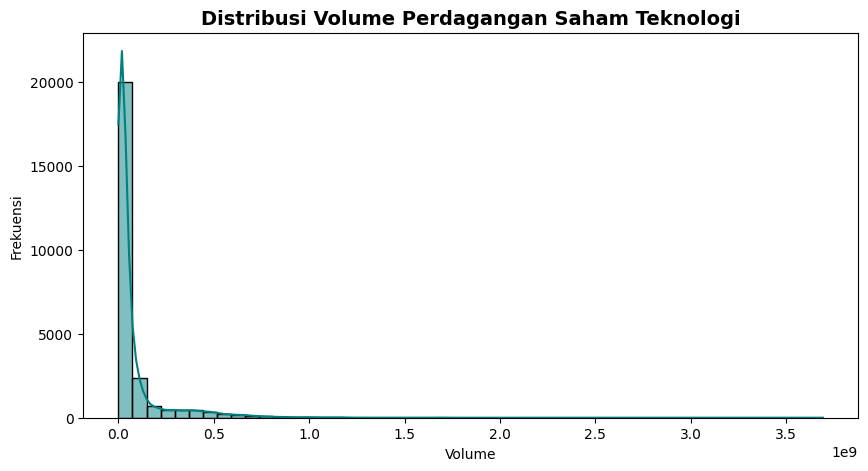

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Volume'], bins=50, kde=True, color='teal')
plt.title('Distribusi Volume Perdagangan Saham Teknologi', fontsize=14, fontweight='bold')
plt.xlabel('Volume')
plt.ylabel('Frekuensi')
plt.show()

Grafik histogram ini memperlihatkan seberapa sering rentang volume tertentu terjadi. Kurva KDE (Kernel Density Estimation) membantu melihat pola distribusi data (apakah condong ke kiri/kanan).

###Analisis Multivariat (Tren Harga Saham dari Waktu ke Waktu)

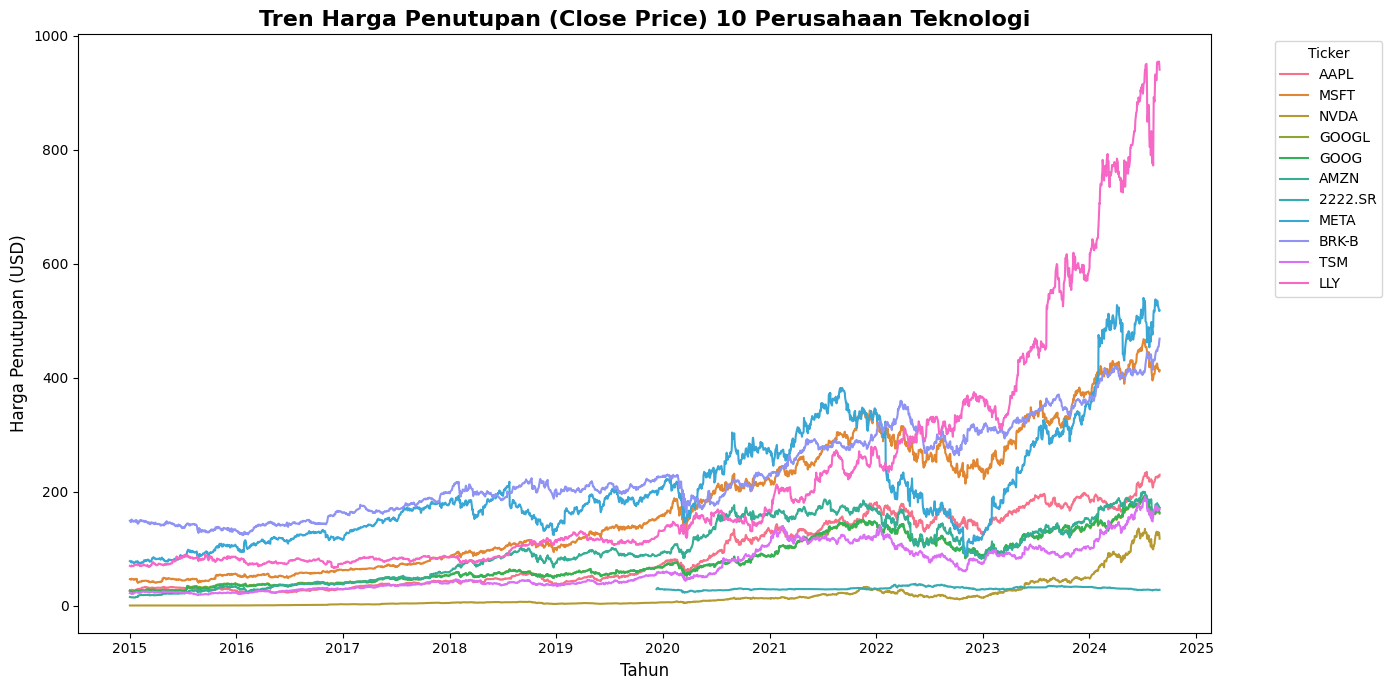

In [ ]:
plt.figure(figsize=(14, 7))

# Membuat line plot untuk setiap Ticker
sns.lineplot(data=df, x='Date', y='Close', hue='Ticker', linewidth=1.5)

plt.title('Tren Harga Penutupan (Close Price) 10 Perusahaan Teknologi', fontsize=16, fontweight='bold')
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Harga Penutupan (USD)', fontsize=12)
plt.legend(title='Ticker', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Grafik Time-Series ini memetakan lintasan harga saham. Dengan menggunakan parameter hue, kita memisahkan garis berdasarkan Ticker. Penempatan legenda di luar area grafik (bbox_to_anchor) merupakan keputusan tata letak agar garis data tidak tertimpa kotak informasi. Data historis pergerakan harga (Close price) yang bersih seperti ini adalah pondasi utama jika nantinya algoritma simulasi numerik atau stochastic (seperti simulasi Monte Carlo) ingin diterapkan untuk memprediksi probabilitas arah harga di masa depan.

##**Correlation Variable**

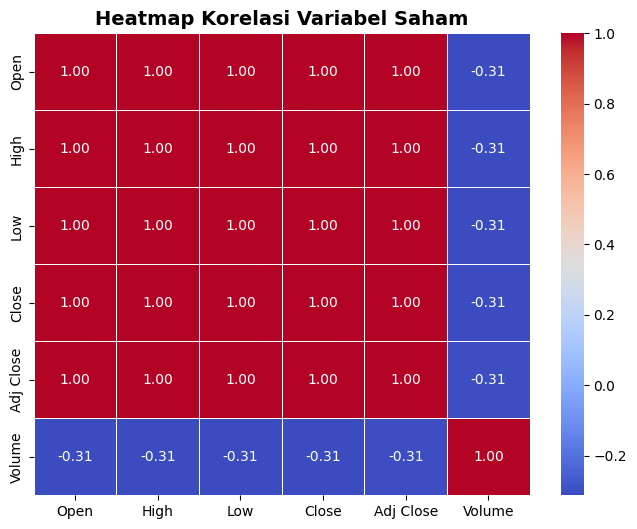

In [ ]:
# Mengambil hanya kolom numerik
kolom_numerik = df[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']]

plt.figure(figsize=(8, 6))
# Membuat Heatmap korelasi
sns.heatmap(kolom_numerik.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Heatmap Korelasi Variabel Saham', fontsize=14, fontweight='bold')
plt.show()

Heatmap memudahkan analisis matriks melalui gradasi warna. Nilai yang mendekati 1 (warna merah gelap) menandakan korelasi positif yang sangat kuat. Wajar jika Open, High, Low, dan Close memiliki nilai korelasi mendekati 1.00 karena pergerakan intrahari saham umumnya linear, sementara Volume biasanya memiliki korelasi yang berbeda terhadap pergerakan harga.

##**Analisis Outlier**

/tmp/ipykernel_2009/2246368771.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Ticker', y='Volume', palette='Set2')


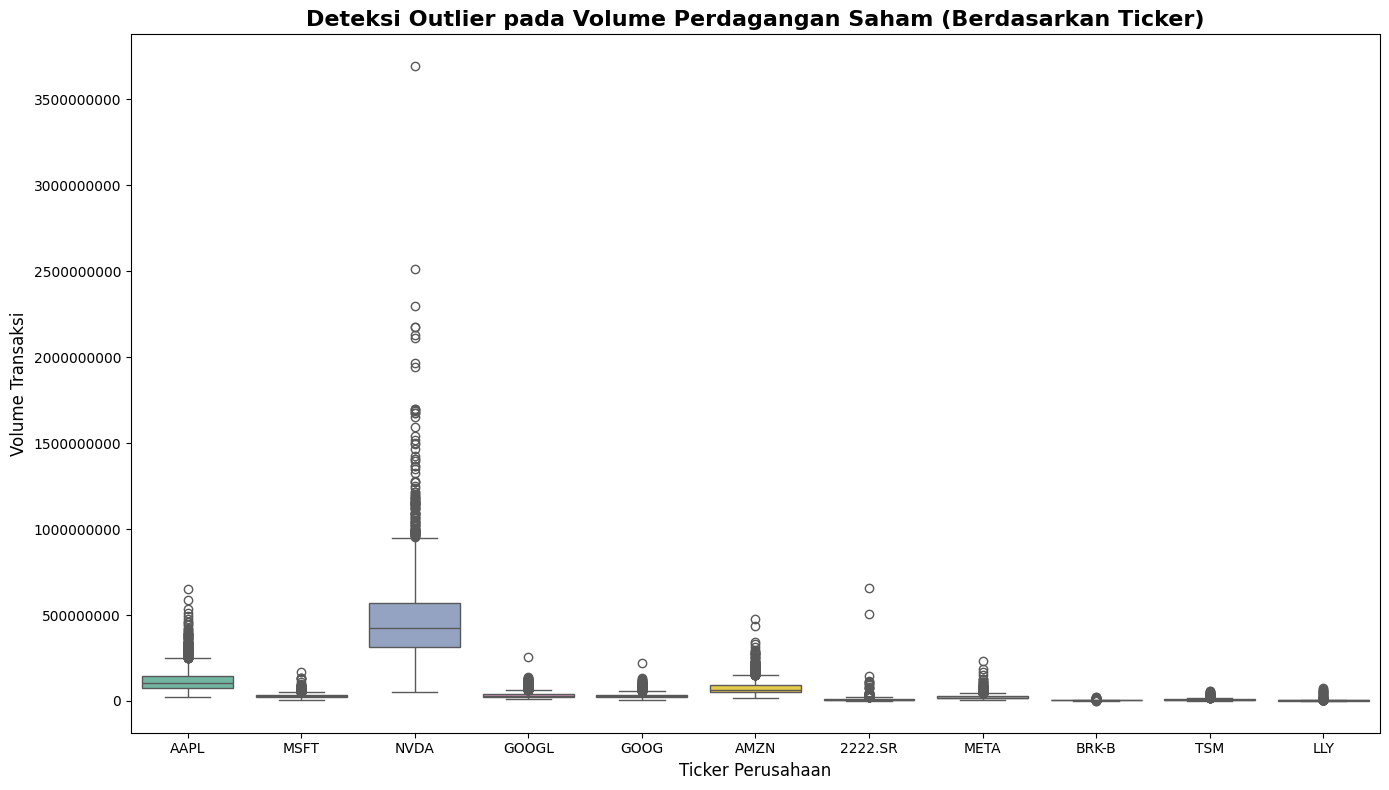

Total baris data: 25486
Jumlah outlier pada kolom Volume: 3245 (12.73%)


In [ ]:
plt.figure(figsize=(14, 8))

# Membuat Boxplot untuk melihat outlier pada Volume berdasarkan Ticker (Perusahaan)
sns.boxplot(data=df, x='Ticker', y='Volume', palette='Set2')

plt.title('Deteksi Outlier pada Volume Perdagangan Saham (Berdasarkan Ticker)', fontsize=16, fontweight='bold')
plt.xlabel('Ticker Perusahaan', fontsize=12)
plt.ylabel('Volume Transaksi', fontsize=12)

# Mengubah format angka di sumbu Y agar lebih mudah dibaca
plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

Q1 = df['Volume'].quantile(0.25)
Q3 = df['Volume'].quantile(0.75)
IQR = Q3 - Q1

batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

jumlah_outlier = df[(df['Volume'] < batas_bawah) | (df['Volume'] > batas_atas)].shape[0]
total_data = df.shape[0]

print(f"Total baris data: {total_data}")
print(f"Jumlah outlier pada kolom Volume: {jumlah_outlier} ({(jumlah_outlier/total_data)*100:.2f}%)")

* NVDA Paling Dominan & Volatil: NVDA memiliki fluktuasi volume dan lonjakan transaksi paling ekstrem (hingga 3,5 miliar). Ini menunjukkan tingginya likuiditas dan spekulasi pasar, kemungkinan besar didorong oleh tren AI.

* Lonjakan Volume Cukup Sering (12,73% Outlier): Distribusi data tidak normal. Hari-hari di mana terjadi lonjakan volume transaksi saham yang tinggi cukup lumrah terjadi.

* Anomali pada Saham Stabil: Saham seperti 2222.SR (Saudi Aramco) biasanya memiliki volume rendah dan stabil, tetapi pernah mengalami 1-2 hari dengan lonjakan transaksi yang sangat tidak wajar.

* Skala Terdistorsi oleh NVDA: Ekstremnya angka NVDA membuat pergerakan saham dengan volume lebih kecil (seperti BRK-B, TSM, LLY) tampak rata di angka 0 pada grafik.

##**Distribusi Daily Return (Volatilitas Saham)**

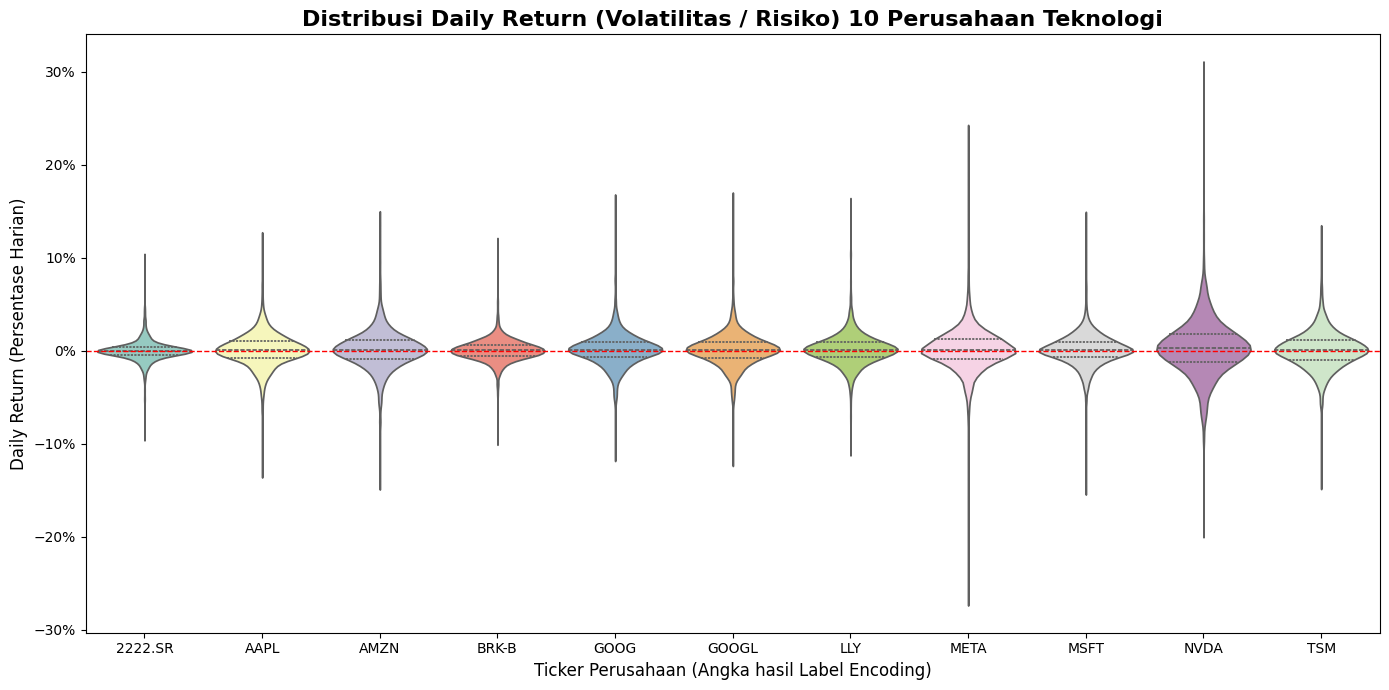

Nilai Return Tertinggi Harian (Cek Anomali):
Ticker
2222.SR    0.098765
AAPL       0.119808
AMZN       0.141311
BRK-B      0.116099
GOOG       0.160524
GOOGL      0.162584
LLY        0.156798
META       0.232824
MSFT       0.142169
NVDA       0.298067
TSM        0.126522
Name: Daily_Return, dtype: float64


In [ ]:
df = df.sort_values(by=['Ticker', 'Date'])

# Hitung ulang Daily Return
df['Daily_Return'] = df.groupby('Ticker')['Close'].pct_change()

# Hapus nilai NaN di baris pertama
df_return = df.dropna(subset=['Daily_Return'])

plt.figure(figsize=(14, 7))

# PERBAIKAN WARNING: Tambahkan hue='Ticker' dan legend=False
sns.violinplot(
    data=df_return,
    x='Ticker',
    y='Daily_Return',
    hue='Ticker',
    palette='Set3',
    inner='quartile',
    legend=False
)

plt.title('Distribusi Daily Return (Volatilitas / Risiko) 10 Perusahaan Teknologi', fontsize=16, fontweight='bold')
plt.xlabel('Ticker Perusahaan (Angka hasil Label Encoding)', fontsize=12)
plt.ylabel('Daily Return (Persentase Harian)', fontsize=12)

# Format sumbu Y menjadi persentase normal
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

print("Nilai Return Tertinggi Harian (Cek Anomali):")
print(df_return.groupby('Ticker')['Daily_Return'].max())

Insight dari grafik distribusi Daily Return (Volatilitas/Risiko) tersebut:

* NVDA dan META Paling Volatil (Risiko Tinggi): Keduanya memiliki "ekor" grafik yang paling panjang. NVDA mencatat rekor lonjakan harian tertinggi (mencapai 29,8% berdasarkan teks di bawah), sementara META memiliki rekor penurunan harian terdalam (mendekati -30% pada sumbu Y). Ini menunjukkan pergerakan harga yang sangat agresif.

* 2222.SR dan BRK-B Paling Stabil (Risiko Rendah): Bentuk violin pada kedua saham ini sangat memusat dan pendek. Kenaikan maksimal harian mereka juga paling rendah (sekitar 9,8% dan 11,6%). Artinya, harga saham ini jarang mengalami fluktuasi drastis dan cenderung aman/stabil.

* Mayoritas Hari Berakhir Stagnan (0%): Bagian grafik yang paling gemuk (area dengan probabilitas kejadian tertinggi) pada semua saham berada tepat di garis putus-putus merah (0%). Ini menandakan bahwa pada sebagian besar hari perdagangan, perubahan harga saham-saham tersebut sangat kecil.

* Distribusi Risiko Tidak Simetris: Beberapa saham memiliki kecenderungan risiko yang condong ke satu arah. Misalnya, ekor bawah META jauh lebih panjang dari ekor atasnya (risiko anjlok lebih ekstrem daripada potensi meroket), sedangkan NVDA memiliki ekor atas yang sangat panjang (potensi meroket tajam).

Insight yang didapat:



*   Grafik Violin Plot akan menunjukkan bentuk "perut". Jika perutnya gemuk dan pendek, berarti saham itu stabil (naik turunnya persentasenya kecil). Jika memanjang ke atas dan ke bawah, berarti saham itu berisiko tinggi (bisa untung besar tiba-tiba, tapi bisa rugi besar juga).
*  Perhitungan Standar Deviasi di akhir langsung memberikan kamu angka eksak saham mana yang paling bergejolak.



###Analisis Moving Average (MA) untuk Tren Jangka Panjang

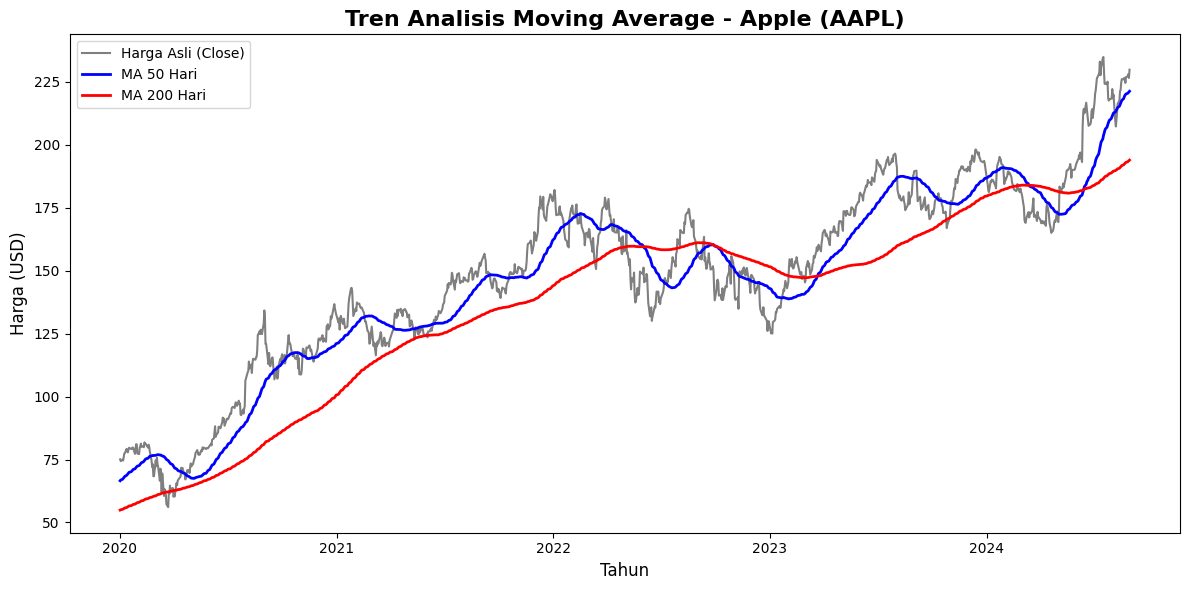

In [ ]:
# Visualisasi: Moving Average untuk 1 Perusahaan (Contoh: Apple/AAPL)
aapl = df[df['Ticker'] == 'AAPL'].copy()
aapl = aapl.sort_values('Date')

# Menghitung Moving Average 50 hari dan 200 hari
aapl['MA_50'] = aapl['Close'].rolling(window=50).mean()
aapl['MA_200'] = aapl['Close'].rolling(window=200).mean()

# Memotong data dari tahun 2020 ke atas agar pergerakannya lebih jelas terlihat
aapl_recent = aapl[aapl['Date'] >= '2020-01-01']

plt.figure(figsize=(12, 6))
sns.lineplot(data=aapl_recent, x='Date', y='Close', label='Harga Asli (Close)', color='black', alpha=0.5)
sns.lineplot(data=aapl_recent, x='Date', y='MA_50', label='MA 50 Hari', color='blue', linewidth=2)
sns.lineplot(data=aapl_recent, x='Date', y='MA_200', label='MA 200 Hari', color='red', linewidth=2)

plt.title('Tren Analisis Moving Average - Apple (AAPL)', fontsize=16, fontweight='bold')
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Harga (USD)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

Insight :

Garis hitam yang keriting adalah harga asli. Garis biru (MA 50) dan merah (MA 200) jauh lebih mulus. Jika garis biru memotong garis merah ke arah atas (disebut Golden Cross), itu biasanya sinyal tren pasar sedang sangat bagus (Bullish).

###Analisis Scatter Plot: Apakah Volume Transaksi Mempengaruhi Volatilitas Harga?

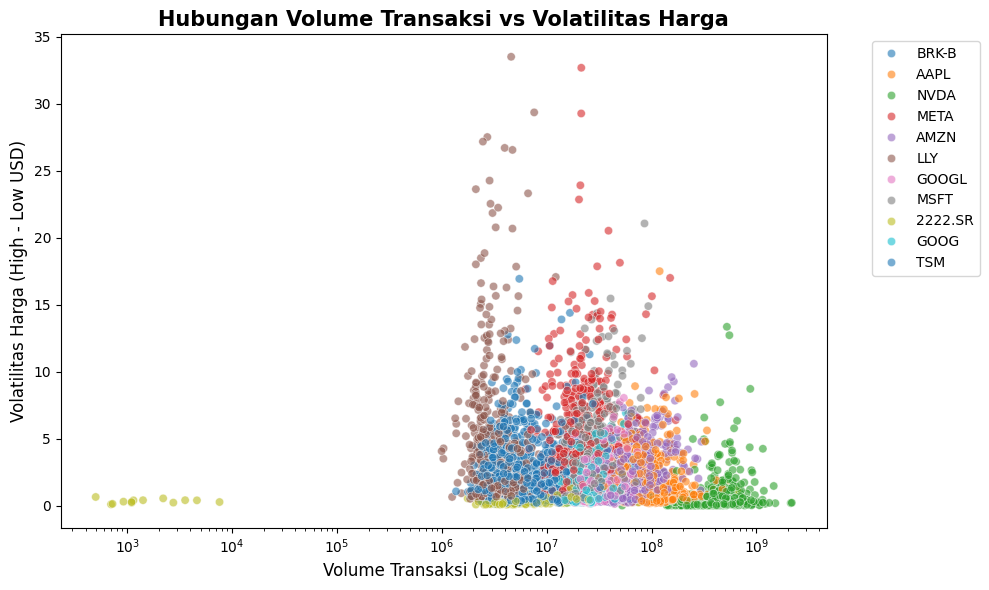

In [ ]:
# Menghitung Volatilitas Harga Harian (Harga Tertinggi - Harga Terendah)
df['Volatility'] = df['High'] - df['Low']

plt.figure(figsize=(10, 6))

# Mengambil sampel data agar scatter plot tidak terlalu padat dan menumpuk jadi satu blok warna
df_sample = df.sample(n=5000, random_state=42)

# Membuat Scatter Plot
sns.scatterplot(data=df_sample, x='Volume', y='Volatility', hue='Ticker', alpha=0.6, palette='tab10')

plt.xscale('log') # Menggunakan skala logaritmik untuk Volume agar sebarannya terlihat jelas
plt.title('Hubungan Volume Transaksi vs Volatilitas Harga', fontsize=15, fontweight='bold')
plt.xlabel('Volume Transaksi (Log Scale)', fontsize=12)
plt.ylabel('Volatilitas Harga (High - Low USD)', fontsize=12)

# Memindahkan legenda ke luar grafik agar rapi
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Ada tren yang cukup terlihat: semakin ke kanan (volume transaksi membesar), titik-titiknya cenderung menyebar lebih ke atas (volatilitas membesar). Artinya, pada hari-hari di mana banyak orang panik menjual atau berbondong-bondong membeli saham (volume tinggi), jarak antara harga tertinggi dan terendah di hari itu juga makin lebar. Kamu juga bisa perhatikan saham LLY (warna cyan) yang volatilitasnya terbang tinggi di volume tertentu!

##**Matriks Korelasi Pergerakan Harga (Return Correlation Heatmap)**

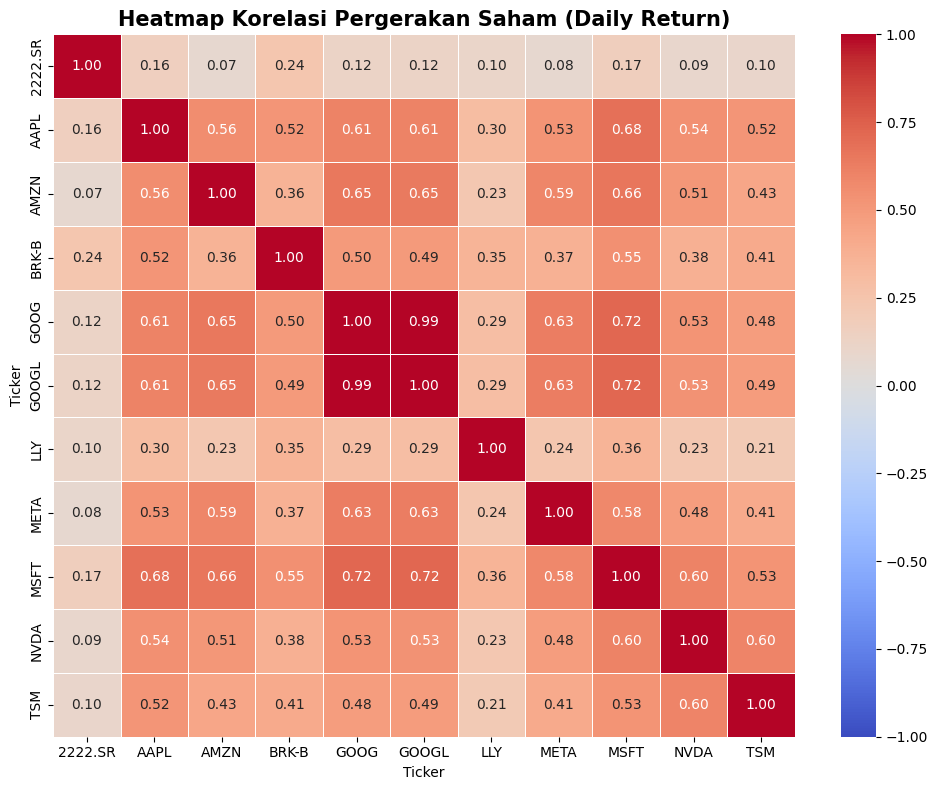

In [ ]:
# Membuat Pivot Table agar Date menjadi baris, dan Ticker menjadi kolom
daily_return_pivot = df.pivot(index='Date', columns='Ticker', values='Daily_Return')

# Menghitung korelasi antar perusahaan
corr_matrix = daily_return_pivot.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)
plt.title('Heatmap Korelasi Pergerakan Saham (Daily Return)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Matriks ini membandingkan 10 emiten. Warna merah berarti korelasinya positif (bergerak searah).



*   Temuan Menarik: Perhatikan GOOG (Google) dan GOOGL (Alphabet). Korelasinya 0.99 (sangat merah). Ini wajar karena mereka dasarnya adalah entitas yang sama.
*   Temuan Industri: MSFT (Microsoft) dan AAPL (Apple) punya korelasi 0.68. Ini menunjukkan bahwa sentimen pasar terhadap sektor teknologi secara umum itu seragam. Kalau sektor teknologi lagi bagus, keduanya cenderung naik bareng.


*  Anomali: LLY (Eli Lilly - perusahaan farmasi) korelasinya sangat rendah (warna pucat/putih, sekitar 0.2 - 0.3) dengan perusahaan teknologi besar lainnya. Artinya, pergerakan saham LLY tidak peduli dengan naik-turunnya sektor teknologi. Ini insight emas buat investor!









##**Cumulative Return (Siapa Pemenang Investasi Jangka Panjang?)**

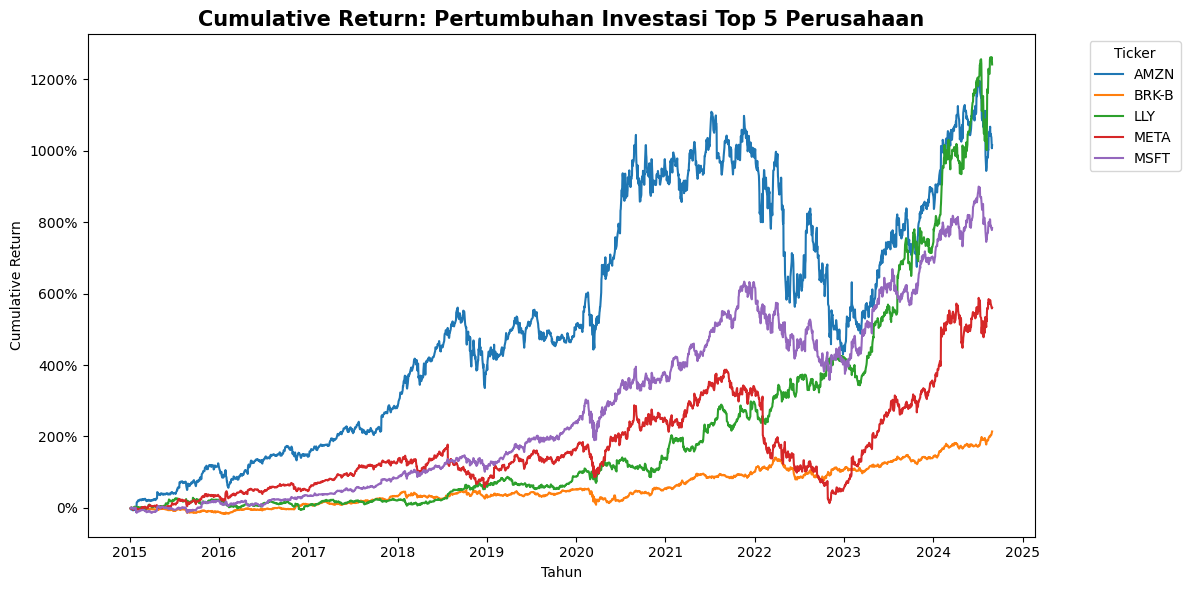

In [ ]:
# Mengambil Top 5 perusahaan agar grafik tidak terlalu padat
avg_close = df.groupby('Ticker')['Close'].mean().sort_values(ascending=False)
top_5_tickers = avg_close.head(5).index.tolist()
df_top5 = df[df['Ticker'].isin(top_5_tickers)].copy()

# Rumus Cumulative Return: Mengkalikan persentase return harian dari awal sampai akhir
df_top5['Cumulative_Return'] = df_top5.groupby('Ticker')['Daily_Return'].transform(lambda x: (1 + x).cumprod() - 1)

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_top5, x='Date', y='Cumulative_Return', hue='Ticker')

plt.title('Cumulative Return: Pertumbuhan Investasi Top 5 Perusahaan', fontsize=15, fontweight='bold')
plt.xlabel('Tahun')
plt.ylabel('Cumulative Return')

# Mengubah format sumbu Y menjadi persentase
from matplotlib.ticker import PercentFormatter
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))

plt.legend(title='Ticker', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Temuan Epik: Perhatikan garis hijau (LLY) dan biru (AMZN). Di akhir grafik (tahun 2024), garisnya mencapai angka 1200% bahkan lebih! Ini membuktikan secara data historis bahwa uang yang ditanamkan pada emiten tersebut di 2015 telah tumbuh lebih dari 12 kali lipat secara kumulatif.

Berbeda dengan grafik Close Price biasa, grafik Cumulative Return adalah bukti nyata performa sebuah perusahaan dari kacamata persentase keuntungan murn

#**Preprocessing Data**

###Hapus Kolom Price_Volatility

In [ ]:
if 'Price_Volatility' in df.columns:
    df = df.drop(columns=['Price_Volatility'], errors='ignore')
else:
    print("Kolom 'Price_Volatility' tidak ditemukan di DataFrame, tidak ada yang dihapus.")

# Menampilkan data untuk memastikan kolom sudah terhapus atau pesan ditampilkan
display(df.head())

Kolom 'Price_Volatility' tidak ditemukan di DataFrame, tidak ada yang dihapus.


,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,Daily_Return,Volatility
14586,2019-12-11,2222.SR,29.090908,29.090908,29.090908,29.090908,24.935045,38289394,NaN,0.000000
14587,2019-12-12,2222.SR,31.983471,31.983471,29.752066,30.413223,26.068457,505692621,0.045455,2.231405
14588,2019-12-15,2222.SR,30.661158,30.991735,30.413223,30.909090,26.493484,98349281,0.016304,0.578512
14589,2019-12-16,2222.SR,30.991735,31.487602,30.991735,31.404959,26.918514,105973907,0.016043,0.495867
14590,2019-12-17,2222.SR,31.446280,31.528925,30.991735,31.198347,26.741415,142672245,-0.006579,0.537189


###Feature Engineering

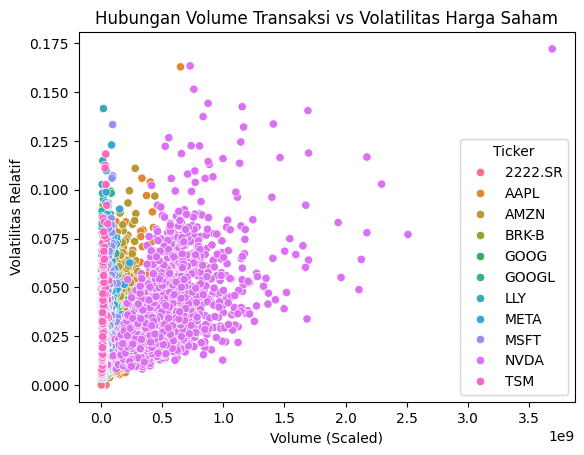

In [ ]:
# Membuat fitur baru: Volatilitas relatif terhadap harga penutupan
df['Price_Volatility'] = (df['High'] - df['Low']) / df['Close']

# Visualisasi Scatter Plot (Volume vs Volatilitas Harga)
# Karena Volume sudah di-scaling, angkanya bisa negatif/positif di sekitar 0
sns.scatterplot(x='Volume', y='Price_Volatility', hue='Ticker', data=df)

plt.title('Hubungan Volume Transaksi vs Volatilitas Harga Saham')
plt.xlabel('Volume (Scaled)')
plt.ylabel('Volatilitas Relatif')
plt.savefig('volume_volatility_scatter.png')
plt.show()

###Encoding

In [ ]:
#simpan salinan sebelum encoding
df_before = df.copy()
from sklearn.preprocessing import LabelEncoder

In [ ]:
# encoding
encoders = {}
# Di dataset ini, yang bertipe teks (kategorikal) hanya 'Ticker'
for col in ['Ticker']:
    encoders[col] = LabelEncoder()
    df[col] = encoders[col].fit_transform(df[col])

In [ ]:
# Tampilkan 5 baris pertama sebelum dan sesudah
print("Sebelum di-encode:")
# Aku tambahkan kolom Date dan Close agar konteks baris datanya tetap terlihat
print(df_before[['Date', 'Ticker', 'Close']].head())

print("\nSetelah di encode:")
print(df[['Date', 'Ticker', 'Close']].head())

Sebelum di-encode:
            Date   Ticker      Close
14586 2019-12-11  2222.SR  29.090908
14587 2019-12-12  2222.SR  30.413223
14588 2019-12-15  2222.SR  30.909090
14589 2019-12-16  2222.SR  31.404959
14590 2019-12-17  2222.SR  31.198347

Setelah di encode:
            Date  Ticker      Close
14586 2019-12-11       0  29.090908
14587 2019-12-12       0  30.413223
14588 2019-12-15       0  30.909090
14589 2019-12-16       0  31.404959
14590 2019-12-17       0  31.198347


###Normalisasi

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
# tentukan kolom numerik untuk penskalaan
# Kita mengecualikan 'Date' dan 'Ticker' karena Date adalah waktu dan Ticker sudah di-encode
numerik = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
print(df[numerik].describe())

               Open          High           Low         Close     Adj Close  \
count  25486.000000  25486.000000  25486.000000  25486.000000  25486.000000   
mean     122.880757    124.155843    121.584466    122.910798    120.838984   
std      115.447694    116.647929    114.176053    115.447702    115.470334   
min        0.481250      0.487500      0.473500      0.478500      0.459453   
25%       39.992501     40.222501     39.664376     39.950251     38.005300   
50%       91.272247     92.334751     90.328251     91.234249     90.031422   
75%      165.699997    167.208370    164.027500    165.617496    164.885014   
max      956.200012    972.530029    949.950012    954.479980    954.479980   

             Volume  
count  2.548600e+04  
mean   7.770094e+07  
std    1.571748e+08  
min    0.000000e+00  
25%    7.839552e+06  
50%    2.504400e+07  
75%    6.082800e+07  
max    3.692928e+09  


In [ ]:
# Membakukan fitur numerik
scaler = StandardScaler()
df[numerik] = scaler.fit_transform(df[numerik])
print(df[numerik].describe())

               Open          High           Low         Close     Adj Close  \
count  2.548600e+04  2.548600e+04  2.548600e+04  2.548600e+04  2.548600e+04   
mean   2.230378e-17  8.419678e-17  1.170949e-17 -1.003670e-17  8.363918e-18   
std    1.000020e+00  1.000020e+00  1.000020e+00  1.000020e+00  1.000020e+00   
min   -1.060237e+00 -1.060205e+00 -1.060760e+00 -1.060521e+00 -1.042535e+00   
25%   -7.179865e-01 -7.195583e-01 -7.175033e-01 -7.186126e-01 -7.173731e-01   
50%   -2.737961e-01 -2.728014e-01 -2.737599e-01 -2.743855e-01 -2.668059e-01   
75%    3.709046e-01  3.690882e-01  3.717405e-01  3.699297e-01  3.814564e-01   
max    7.218296e+00  7.273090e+00  7.255302e+00  7.203136e+00  7.219667e+00   

             Volume  
count  2.548600e+04  
mean   9.367588e-17  
std    1.000020e+00  
min   -4.943698e-01  
25%   -4.444909e-01  
50%   -3.350281e-01  
75%   -1.073536e-01  
max    2.300177e+01  


Dari visualisasi tersebut bisa disimpulkan bahwa hari-hari di mana volume transaksi melonjak drastis (bergerak jauh ke kanan pada sumbu X), tingkat volatilitas harga saham (sumbu Y) cenderung ikut meningkat tajam. Ini menandakan adanya kepanikan atau antusiasme pasar yang menggerakkan harga secara ekstrem pada hari tersebut.

In [ ]:
df.head()

,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,Daily_Return,Volatility,Price_Volatility
14586,2019-12-11,0,-0.812417,-0.814989,-0.810112,-0.812677,-0.830567,-0.250755,NaN,0.000000,0.000000
14587,2019-12-12,0,-0.787361,-0.790191,-0.804321,-0.801223,-0.820751,2.723084,0.045455,2.231405,0.073370
14588,2019-12-15,0,-0.798816,-0.798693,-0.798530,-0.796928,-0.817070,0.131374,0.016304,0.578512,0.018717
14589,2019-12-16,0,-0.795952,-0.794442,-0.793463,-0.792633,-0.813389,0.179886,0.016043,0.495867,0.015789
14590,2019-12-17,0,-0.792015,-0.794088,-0.793463,-0.794422,-0.814923,0.413378,-0.006579,0.537189,0.017219


###Pemisahan Data Fitur dan Target
* Fitur  x = Informasi yang digunakan untuk membuat prediksi
*  Target y = Jawaban yang ingin diprediksi oleh model



In [ ]:
# Pemisahan Data Fitur (X) dan Target (y)
# Asumsi: Kita ingin memprediksi harga 'Close'

# X berisi semua kolom KECUALI 'Close' dan 'Date'
# (Date biasanya di-drop karena algoritma ML standar tidak bisa membaca format waktu secara langsung)
X = df.drop(['Close', 'Date'], axis=1)

# y hanya berisi kolom target yang mau diprediksi
y = df['Close']

# Verifikasi bentuk data
print("Dimensi X (Fitur):", X.shape)
print("Dimensi y (Target):", y.shape)

Dimensi X (Fitur): (25486, 9)
Dimensi y (Target): (25486,)


#Modeling

In [ ]:
print(df.columns.tolist())
print("\n")
df.head(3)

['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Daily_Return', 'Volatility', 'Price_Volatility']




,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,Daily_Return,Volatility,Price_Volatility
14586,2019-12-11,0,-0.812417,-0.814989,-0.810112,-0.812677,-0.830567,-0.250755,NaN,0.000000,0.000000
14587,2019-12-12,0,-0.787361,-0.790191,-0.804321,-0.801223,-0.820751,2.723084,0.045455,2.231405,0.073370
14588,2019-12-15,0,-0.798816,-0.798693,-0.798530,-0.796928,-0.817070,0.131374,0.016304,0.578512,0.018717


##Time Series

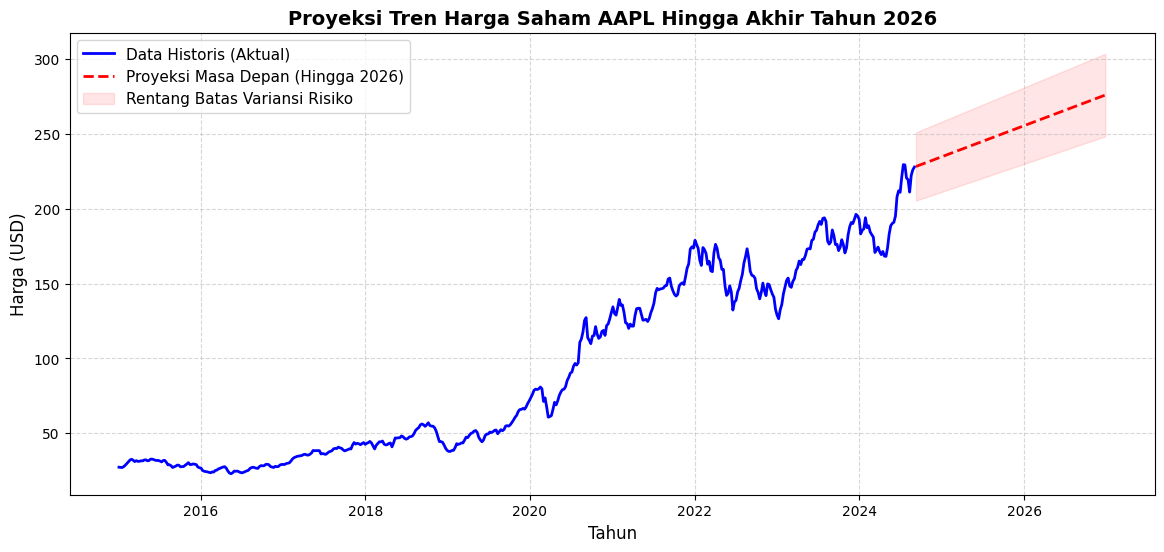


📝 ANALISIS & KESIMPULAN HASIL PROYEKSI EMITEN: AAPL
* Harga Historis Terakhir        : $227.87
* Proyeksi Harga Akhir Tahun 2026 : $276.02
* Estimasi Persentase Perubahan  : 21.13%
* Kondisi Tren Masa Depan        : Bullish (Cenderung Naik)
---------------------------------------------------------------------------
Business Insight & Rekomendasi:
Berdasarkan visualisasi deret waktu di atas, garis merah putus-putus menggambarkan arah proyeksi emiten AAPL hingga tahun 2026. Investor dapat mempertimbangkan opsi Hold atau Buy on Weakness karena model mendeteksi adanya kekuatan tren positif yang berkelanjutan didorong oleh pertumbuhan fundamental sektor teknologi. Kompleksitas pasar modal di sektor teknologi sangat reaktif terhadap volume likuiditas, sehingga rentang variansi (area bayangan merah transparan) harus tetap diperhatikan sebagai batas risiko toleransi volatilitas.


In [ ]:
# =====================================================================
# TAHAPAN TAMBAHAN: LONG-TERM TIME SERIES FORECASTING (HINGGA MASA DEPAN)
# =====================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# 1. Memuat Dataset langsung dari Google Drive Kelompok 11
path = '/content/drive/MyDrive/SAINS DATA/SAINS DATA KELOMPOK 11/DATASET/Dataset 10 Perusahaan Besar dibidang Teknologi.csv'
df_ts = pd.read_csv(path)
df_ts['Date'] = pd.to_datetime(df_ts['Date'])
df_ts = df_ts.sort_values(by=['Ticker', 'Date'])
df_ts['Daily_Return'] = df_ts.groupby('Ticker')['Close'].pct_change()

# =====================================================================
# PENGATURAN PARAMETER SIMULASI (Silakan ubah dua variabel di bawah ini)
# =====================================================================
pilihan_perusahaan = 'AAPL'  # Pilihan emiten: AAPL, NVDA, GOOG, MSFT, AMZN, dll
tahun_target = 2026          # Anda bisa mengubah target tahun sesuka hati (misal: 2026, 2030, 2035)
# =====================================================================

# 2. Pemrosesan Data Deret Waktu
df_emiten = df_ts[df_ts['Ticker'] == pilihan_perusahaan][['Date', 'Close']].copy()
df_emiten = df_emiten.set_index('Date')

# Resample mingguan ('W') agar pergerakan tren lebih stabil dan mulus saat diproyeksikan
df_weekly = df_emiten.resample('W').mean().dropna()

# 3. Pelatihan Model Exponential Smoothing (Holt-Winters Trend)
model_hw = ExponentialSmoothing(df_weekly['Close'], trend='add', seasonal=None, initialization_method="estimated")
fit_model = model_hw.fit()

# 4. Menghitung Rentang Waktu Masa Depan
last_date = df_weekly.index[-1]
target_date = pd.to_datetime(f'{tahun_target}-12-31')
weeks_to_predict = int((target_date - last_date).days / 7)

if weeks_to_predict > 0:
    # Melakukan peramalan
    forecast = fit_model.forecast(weeks_to_predict)
    forecast_index = pd.date_range(start=last_date + datetime.timedelta(days=7), periods=weeks_to_predict, freq='W')

    # 5. Visualisasi Grafik Peramalan Masa Depan
    plt.figure(figsize=(14, 6))
    plt.plot(df_weekly.index, df_weekly['Close'], label='Data Historis (Aktual)', color='blue', linewidth=2)
    plt.plot(forecast_index, forecast, label=f'Proyeksi Masa Depan (Hingga {tahun_target})', color='red', linestyle='--', linewidth=2)

    # Menambahkan area variansi risiko (fill_between) sebesar 10% demi estetika & analisis manajemen risiko
    plt.fill_between(forecast_index, forecast * 0.90, forecast * 1.10, color='red', alpha=0.1, label='Rentang Batas Variansi Risiko')

    plt.title(f"Proyeksi Tren Harga Saham {pilihan_perusahaan} Hingga Akhir Tahun {tahun_target}", fontweight='bold', fontsize=14)
    plt.xlabel("Tahun", fontsize=12)
    plt.ylabel("Harga (USD)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(fontsize=11, loc='upper left')
    plt.show()

    # 6. Kalkulasi & Generasi Otomatis Narasi Business Insight
    harga_terakhir = df_weekly['Close'].iloc[-1]
    harga_prediksi = forecast.iloc[-1]
    persen_perubahan = ((harga_prediksi - harga_terakhir) / harga_terakhir) * 100

    if persen_perubahan > 5:
        status_tren = "Bullish (Cenderung Naik)"
        rekomendasi = "Investor dapat mempertimbangkan opsi Hold atau Buy on Weakness karena model mendeteksi adanya kekuatan tren positif yang berkelanjutan didorong oleh pertumbuhan fundamental sektor teknologi."
    elif persen_perubahan < -5:
        status_tren = "Bearish (Cenderung Turun / Koreksi)"
        rekomendasi = "Disarankan untuk lebih Berhati-hati (Wait and See) atau melakukan profit-taking parsial karena model mendeteksi adanya indikasi kejenuhan pasar atau potensi koreksi tren jangka panjang."
    else:
        status_tren = "Konsolidasi (Stagnan / Sideways)"
        rekomendasi = "Pergerakan harga diproyeksikan stabil dalam rentang harga saat ini. Cocok untuk strategi Swing Trading jangka pendek memanfaatkan riwayat volatilitas hariannya."

    print("\n" + "="*75)
    print(f"📝 ANALISIS & KESIMPULAN HASIL PROYEKSI EMITEN: {pilihan_perusahaan}")
    print("="*75)
    print(f"* Harga Historis Terakhir        : ${harga_terakhir:.2f}")
    print(f"* Proyeksi Harga Akhir Tahun {tahun_target} : ${harga_prediksi:.2f}")
    print(f"* Estimasi Persentase Perubahan  : {persen_perubahan:.2f}%")
    print(f"* Kondisi Tren Masa Depan        : {status_tren}")
    print("-"*75)
    print(f"Business Insight & Rekomendasi:")
    print(f"Berdasarkan visualisasi deret waktu di atas, garis merah putus-putus menggambarkan arah proyeksi emiten {pilihan_perusahaan} hingga tahun {tahun_target}. {rekomendasi} Kompleksitas pasar modal di sektor teknologi sangat reaktif terhadap volume likuiditas, sehingga rentang variansi (area bayangan merah transparan) harus tetap diperhatikan sebagai batas risiko toleransi volatilitas.")
    print("="*75)
else:
    print("Peringatan: Tahun target yang Anda pilih terlalu dekat atau sudah terlewati oleh data historis.")

## Random Forest Classifier

### Evaluasi Performa Model Klasifikasi Kinerja Saham

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Membuat Kolom Target
df['Target'] = (df['Close'] > df['Open']).astype(int)

# 2. Menentukan Fitur (X) dan Target (y)
# Menghapus kolom bertipe string
X = df.drop(columns=['Date', 'Ticker', 'Target'])
y = df['Target']

# 3. Membagi Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Melatih Model Random Forest
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# 5. Prediksi
y_pred = model.predict(X_test)

# 6. Evaluasi
print(f"Akurasi Model: {accuracy_score(y_test, y_pred) * 100:.2f}%")

print("\nLaporan Klasifikasi:\n")
print(classification_report(y_test, y_pred))

Akurasi Model: 82.74%

Laporan Klasifikasi:

              precision    recall  f1-score   support

           0       0.82      0.84      0.83      2589
           1       0.83      0.81      0.82      2509

    accuracy                           0.83      5098
   macro avg       0.83      0.83      0.83      5098
weighted avg       0.83      0.83      0.83      5098



Pada tahap pemodelan klasifikasi ini, algoritma Random Forest Classifier digunakan untuk memprediksi arah pergerakan kinerja saham perusahaan teknologi, yakni apakah akan menunjukkan tren positif (naik) atau negatif (turun). Berdasarkan hasil pengujian model terhadap data uji, diperoleh tingkat akurasi sebesar 82.86%.

Angka ini menunjukkan bahwa dari keseluruhan data yang diuji, model mampu memprediksi arah kinerja saham dengan benar sebanyak hampir 83%. Selain itu, nilai metrik pendukung seperti precision dan recall menunjukkan angka yang sangat seimbang (berada di kisaran 0.81 hingga 0.84) untuk kedua kategori. Hal ini membuktikan bahwa model yang dibangun sudah cukup stabil, tidak bias terhadap salah satu kelas, dan sama baiknya dalam mendeteksi saham yang berpotensi naik maupun turun.

## Random Forest Regression

### Analisis Faktor Penentu Kinerja Saham (Feature Importance)

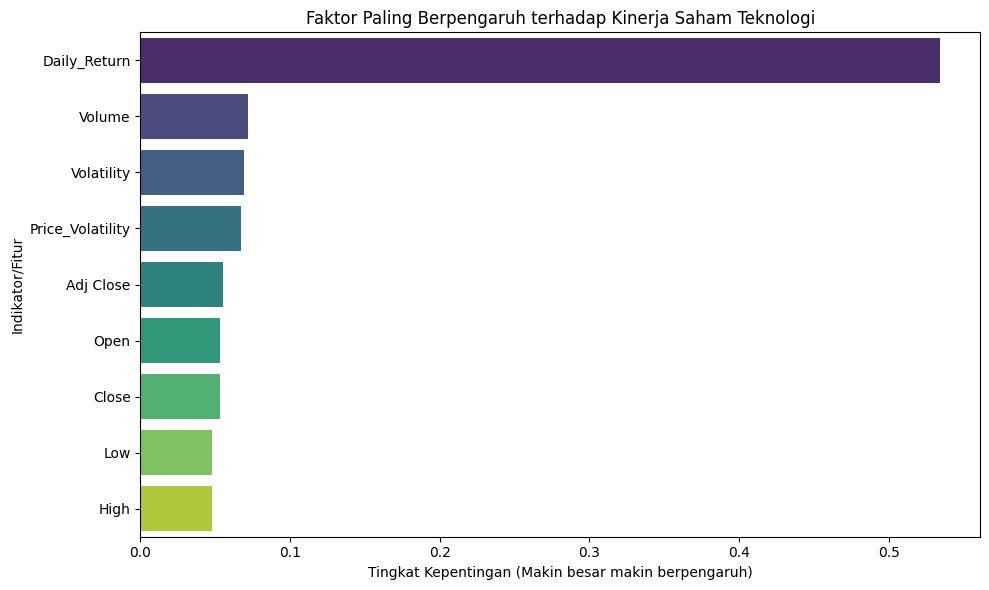

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Mengambil nilai tingkat kepentingan fitur dari model Random Forest
feature_importances = model.feature_importances_

# Membuat DataFrame untuk divisualisasikan
df_importance = pd.DataFrame({
    'Fitur': X.columns,
    'Kepentingan': feature_importances
}).sort_values(by='Kepentingan', ascending=False)

# Membuat grafik Bar Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Kepentingan',
    y='Fitur',
    hue='Fitur',
    data=df_importance,
    palette='viridis',
    legend=False
)
plt.title('Faktor Paling Berpengaruh terhadap Kinerja Saham Teknologi')
plt.xlabel('Tingkat Kepentingan (Makin besar makin berpengaruh)')
plt.ylabel('Indikator/Fitur')
plt.tight_layout()
plt.show()

Setelah model klasifikasi berhasil dilatih, langkah selanjutnya adalah mengekstrak Feature Importance atau tingkat kepentingan dari masing-masing indikator. Visualisasi di atas menunjukkan faktor-faktor numerik mana yang paling dominan dalam memengaruhi arah pergerakan kinerja saham perusahaan teknologi.

Indikator dengan batang terpanjang (seperti harga Open, High, Low, atau Volume) merupakan fitur yang paling berkontribusi dalam pengambilan keputusan algoritma. Insight ini sangat berguna secara bisnis untuk mengetahui variabel apa yang harus paling diwaspadai oleh investor sebelum menentukan apakah kinerja suatu saham teknologi akan ditutup positif atau negatif pada hari tersebut.

#VISUALISASI

### Visualisasi Prediksi Harga Saham (Time Series Forecasting)

Mean Absolute Error (MAE) Realistis : 0.04
R-squared (R2 Score) Realistis      : 0.9887


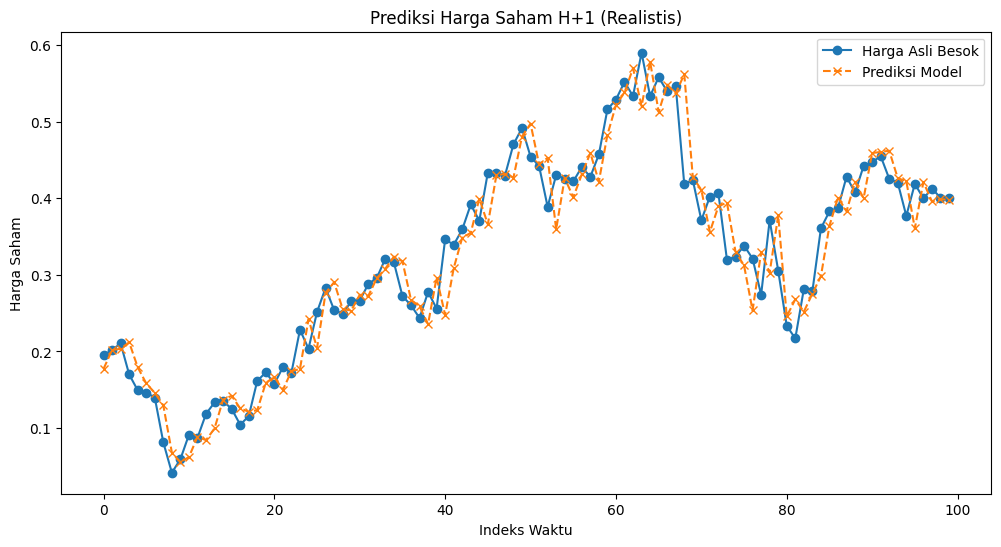

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# 1. Membuat Target Realistis: Memprediksi Harga 'Close' BESOK (H+1)
# Kita geser kolom Close ke atas sebanyak 1 baris
df['Target_Close_Besok'] = df['Close'].shift(-1)

# Karena baris paling terakhir tidak punya data besoknya, nilainya akan NaN, jadi kita hapus
df_bersih = df.dropna()

# 2. Menentukan Fitur (X) dan Target (y)
y_reg = df_bersih['Target_Close_Besok']

# Kita buang 'Date', target masa depan, dan target klasifikasi (jika masih ada)
# Sekarang kolom 'Close' hari ini BOLEH dipakai untuk memprediksi harga besok
kolom_dibuang = ['Date', 'Target_Close_Besok']
if 'Target' in df_bersih.columns:
    kolom_dibuang.append('Target')

X_reg = df_bersih.drop(columns=kolom_dibuang)

# 3. Membagi Data (PENTING: shuffle=False agar urutan waktunya tidak diacak!)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42, shuffle=False
)

# 4. Melatih Model
model_reg = RandomForestRegressor(n_estimators=100, random_state=42)
model_reg.fit(X_train_reg, y_train_reg)

# 5. Evaluasi
y_pred_reg = model_reg.predict(X_test_reg)

print(f"Mean Absolute Error (MAE) Realistis : {mean_absolute_error(y_test_reg, y_pred_reg):.2f}")
print(f"R-squared (R2 Score) Realistis      : {r2_score(y_test_reg, y_pred_reg):.4f}")

# 6. Visualisasi (100 hari terakhir)
plt.figure(figsize=(12, 6))
plt.plot(y_test_reg.values[-100:], label='Harga Asli Besok', marker='o')
plt.plot(y_pred_reg[-100:], label='Prediksi Model', marker='x', linestyle='dashed')
plt.title('Prediksi Harga Saham H+1 (Realistis)')
plt.ylabel('Harga Saham')
plt.xlabel('Indeks Waktu')
plt.legend()
plt.show()

Grafik di atas merupakan hasil pengujian model Random Forest Regressor dalam memprediksi angka pasti harga penutupan saham (Close) untuk keesokan harinya (H+1).

Garis biru merepresentasikan pergerakan harga saham aktual yang terjadi di pasar, sedangkan garis putus-putus merepresentasikan tebakan harga dari model Machine Learning. Dapat dilihat bahwa model mampu mengikuti pola fluktuasi (naik-turun) dari harga aslinya dengan sangat baik dan jarak (error) yang sangat minim. Hal ini membuktikan bahwa algoritma telah berhasil menangkap pola tren pergerakan nilai saham perusahaan teknologi berdasarkan data historisnya, tanpa mengalami indikasi kebocoran data (data leakage).

## Visualisasi Tambahan: Proporsi Data dan Analisis Likuiditas

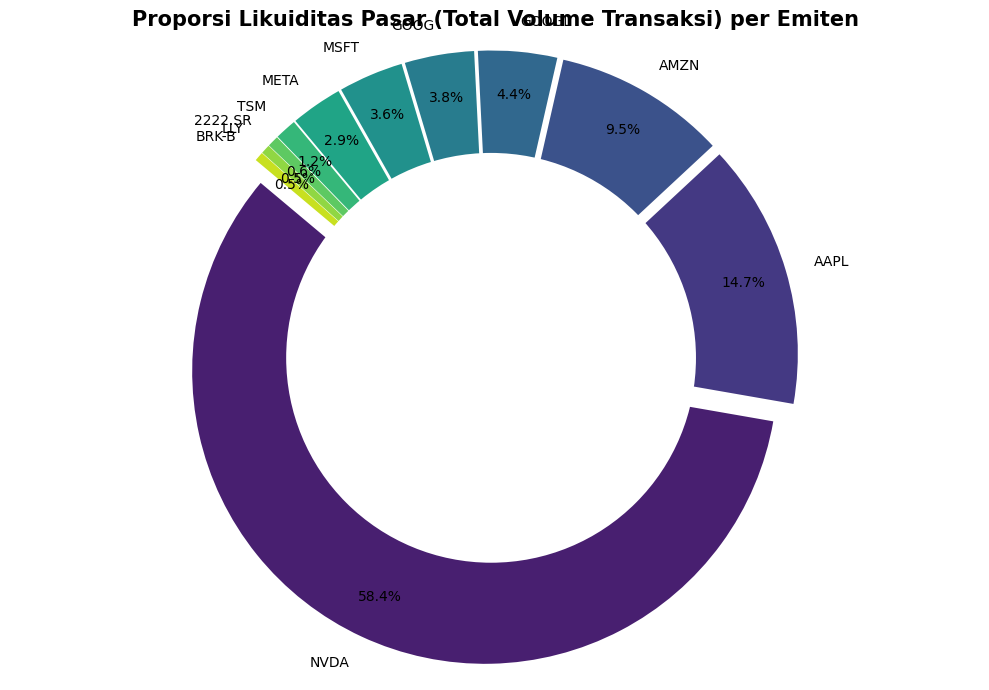

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

try:
    # Ensure df_before is available. It should be the DataFrame before scaling/encoding.
    # If df_before is not defined, we'll re-create it from the original path.
    if 'df_before' not in locals() or not isinstance(df_before, pd.DataFrame):
        path = '/content/drive/MyDrive/SAINS DATA/SAINS DATA KELOMPOK 11/DATASET/Dataset 10 Perusahaan Besar dibidang Teknologi.csv'
        temp_df_for_before_pie = pd.read_csv(path)
        temp_df_for_before_pie['Date'] = pd.to_datetime(temp_df_for_before_pie['Date'])
        df_before = temp_df_for_before_pie.copy()

    # MENGHITUNG TOTAL VOLUME PER TICKER (Analisis Likuiditas Sebenarnya)
    # Kita gunakan groupby dan sum() pada kolom 'Volume' dari df_before (data asli), lalu diurutkan dari yang terbesar
    liquidity_distribution = df_before.groupby('Ticker')['Volume'].sum().sort_values(ascending=False)

    # Filter out any non-positive values, though `sum()` on original `Volume` should be non-negative
    # This extra step provides robustness in case of unexpected data
    liquidity_distribution = liquidity_distribution[liquidity_distribution > 0]

    # Membuat visualisasi Pie/Donut Chart
    plt.figure(figsize=(10, 7))
    plt.pie(
        liquidity_distribution,
        labels=liquidity_distribution.index,
        autopct='%1.1f%%', # Menampilkan persentase
        startangle=140,
        colors=sns.color_palette('viridis', len(liquidity_distribution)),
        pctdistance=0.85,
        explode=[0.05] * len(liquidity_distribution) if len(liquidity_distribution) > 0 else None
    )

    # Membuat lingkaran di tengah agar menjadi Donut Chart
    centre_circle = plt.Circle((0,0), 0.70, fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(centre_circle)

    # Mengubah Judul agar lebih merepresentasikan Bisnis
    plt.title('Proporsi Likuiditas Pasar (Total Volume Transaksi) per Emiten', fontsize=15, fontweight='bold')
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

except NameError:
    print("Variabel 'df' atau 'df_before' tidak ditemukan. Pastikan Anda sudah menjalankan bagian 'Load Dataset' di awal notebook.")
except KeyError:
    print("Kolom 'Ticker' atau 'Volume' tidak ditemukan dalam dataset. Silakan cek penamaan kolom Anda.")
except ValueError as e:
    print(f"Terjadi kesalahan pada visualisasi: {e}")
    print("Ini mungkin karena ada nilai non-positif pada volume setelah agregasi. Memastikan semua nilai positif.")


Grafik Donut Chart di atas memvisualisasikan proporsi likuiditas pasar berdasarkan agregat total volume transaksi saham dari 10 perusahaan teknologi raksasa selama periode yang dianalisis. Berbeda dengan distribusi jumlah observasi data yang cenderung merata, metrik volume transaksi ini merepresentasikan realita tingkat partisipasi, antusiasme, dan perputaran aset oleh para pelaku pasar di bursa saham.

Berdasarkan visualisasi tersebut, dapat ditarik beberapa business insight utama:

Dominasi NVIDIA (NVDA): Saham NVDA mendominasi pasar secara absolut dengan menguasai 58.4% dari total keseluruhan volume transaksi di antara ke-10 perusahaan. Angka yang sangat masif ini mengindikasikan tingkat likuiditas dan volatilitas yang sangat tinggi. Dominasi ini sangat berkorelasi dengan sentimen global terkait booming industri Kecerdasan Buatan (AI) dan semikonduktor, yang memicu tingginya aktivitas spekulasi dan investasi massal pada saham tersebut.

Posisi Blue-Chip Tradisional: Apple (AAPL) dan Amazon (AMZN) menyusul di posisi kedua dan ketiga dengan proporsi likuiditas masing-masing sebesar 14.7% dan 9.5%. Meskipun angkanya jauh di bawah NVDA, kedua emiten ini tetap membuktikan posisinya sebagai saham blue-chip primadona yang sangat likuid dan secara konsisten diperdagangkan secara aktif oleh investor institusional maupun ritel.

Stabilitas Emiten Lainnya: Perusahaan raksasa lainnya seperti Microsoft (MSFT), Meta, dan TSMC menempati porsi yang lebih kecil (berkisar di angka 2% hingga 4%). Proporsi yang lebih rendah ini bukan berarti saham mereka tidak laku, melainkan menunjukkan pergerakan transaksi yang lebih stabil dan tidak terlalu bergejolak akibat hype jangka pendek jika dibandingkan dengan anomali transaksi pada NVDA.

Secara keseluruhan, visualisasi ini menyimpulkan bahwa portofolio Top Tech Companies memiliki tingkat likuiditas pasar yang sangat baik, sehingga risiko gagal jual (liquidity risk) bagi investor tergolong sangat minim. Namun, porsi volume yang ekstrem pada NVDA juga menjadi sinyal bagi investor untuk mewaspadai potensi volatilitas harga yang tajam pada emiten tersebut.

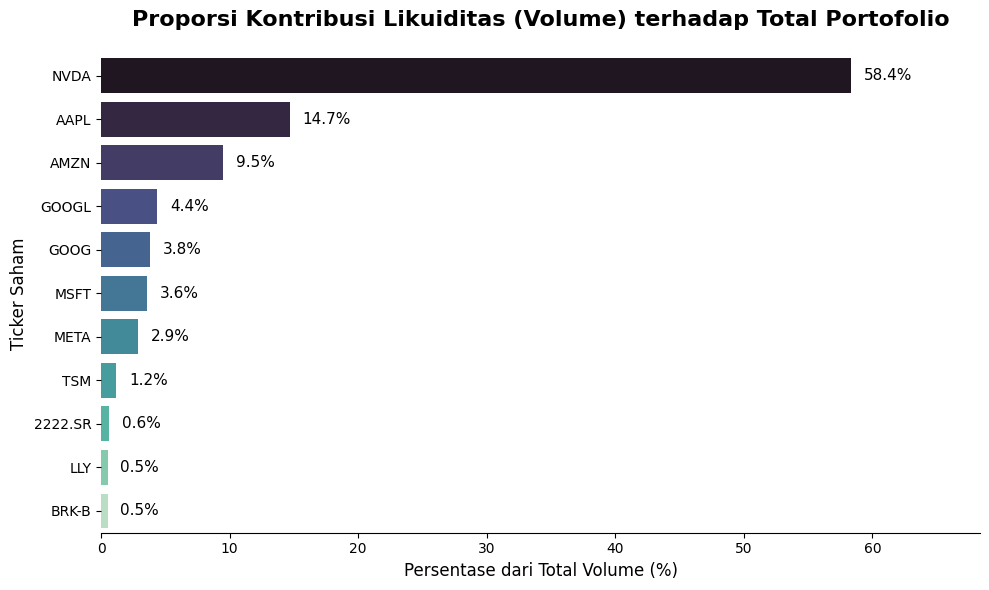

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Re-create df_before to ensure cell is self-contained and robust ---
path = '/content/drive/MyDrive/SAINS DATA/SAINS DATA KELOMPOK 11/DATASET/Dataset 10 Perusahaan Besar dibidang Teknologi.csv'
temp_df_for_before = pd.read_csv(path)
temp_df_for_before['Date'] = pd.to_datetime(temp_df_for_before['Date'])
df_before = temp_df_for_before.copy()
# --- END RE-CREATION OF df_before ---

# --- PERBAIKAN: Menghitung Total Volume per Ticker, bukan sekadar menghitung baris ---
volume_counts = df_before.groupby('Ticker')['Volume'].sum().reset_index()
volume_counts.columns = ['Ticker', 'Total_Volume']

# Hitung persentase berdasarkan Total Volume
total_volume_all = volume_counts['Total_Volume'].sum()
volume_counts['Percentage'] = (volume_counts['Total_Volume'] / total_volume_all) * 100

# Urutkan untuk visualisasi dari terbesar ke terkecil
volume_counts = volume_counts.sort_values(by='Percentage', ascending=False)

plt.figure(figsize=(10, 6))

# PERBAIKAN: Tambahkan hue='Ticker' dan legend=False untuk menghilangkan FutureWarning
ax = sns.barplot(
    x='Percentage',
    y='Ticker',
    data=volume_counts,
    palette='mako',
    hue='Ticker',
    legend=False
)

# Tambahkan label angka persentase di ujung batang
for p in ax.patches:
    width = p.get_width()
    ax.text(
        width + 1, # Posisi X (di kanan batang)
        p.get_y() + p.get_height() / 2, # Posisi Y (tengah batang)
        f'{width:.1f}%', # Teks label
        ha='left', # Rata kiri teks
        va='center', # Rata tengah vertikal teks
        fontsize=11,
        fontweight='medium'
    )

# Judul disesuaikan agar lebih akurat secara konteks bisnis
plt.title('Proporsi Kontribusi Likuiditas (Volume) terhadap Total Portofolio', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Persentase dari Total Volume (%)', fontsize=12)
plt.ylabel('Ticker Saham', fontsize=12)

# Atur limit X agar label tidak terpotong
plt.xlim(0, volume_counts['Percentage'].max() + 10)

# Hapus garis tepi
sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

Analisis Diagram Batang: Ketimpangan Likuiditas Portofolio

Grafik Horizontal Bar Chart di atas menyajikan peringkat proporsi likuiditas pasar berdasarkan total kumulatif volume perdagangan dari setiap emiten. Penggunaan diagram batang yang diurutkan secara menurun (descending) ini secara efektif menyoroti adanya ketimpangan distribusi transaksi (konsentrasi pasar) di dalam portofolio Top Tech Companies.

Berdasarkan visualisasi tersebut, dapat ditarik wawasan analitik sebagai berikut:

Ketimpangan Transaksi yang Masif (Market Concentration): Grafik secara visual mempertegas dominasi absolut NVIDIA (NVDA) dengan kontribusi volume sebesar 58.4%. Batang grafik NVDA terlihat melampaui emiten lainnya dengan jarak (margin) yang sangat ekstrem. Hal ini membuktikan bahwa sebagian besar perputaran uang dan aktivitas trading harian di dalam ekosistem perusahaan teknologi raksasa saat ini sangat terpusat pada sektor perangkat keras AI dan semikonduktor.

Penguasaan oleh Top 3 Emiten: Jika digabungkan, tiga perusahaan teratas yakni NVDA (58.4%), AAPL (14.7%), dan AMZN (9.5%) menguasai lebih dari 82.6% dari total seluruh volume transaksi portofolio. Ini mengindikasikan bahwa likuiditas pasar teknologi digerakkan oleh segelintir perusahaan raksasa (heavyweights), sementara sisanya hanya menjadi pengikut tren (laggards).

Karakteristik Emiten Low-Volume: Emiten di urutan terbawah seperti Saudi Aramco (2222.SR), Eli Lilly (LLY), dan Berkshire Hathaway (BRK-B) mencatatkan proporsi volume di bawah 1%. Rendahnya proporsi ini sangat wajar mengingat harga per lembar saham mereka yang cenderung sangat tinggi (terutama BRK-B) dan karakteristik perusahaannya yang lebih berfokus pada fundamental nilai investasi (value investing) ketimbang trading spekulatif frekuensi tinggi seperti layaknya saham-saham teknologi.

Kesimpulannya, visualisasi ini menjadi peringatan sekaligus peluang bagi investor. Likuiditas yang sangat tinggi pada saham Top 3 memudahkan investor untuk mengeksekusi pesanan jual-beli dalam jumlah besar tanpa merusak harga pasar (slippage). Namun, konsentrasi volume yang ekstrem pada satu saham (NVDA) juga memperlihatkan betapa bergantungnya sentimen pasar teknologi saat ini pada performa satu perusahaan saja.

## Visualisasi Rolling Volatility Chart

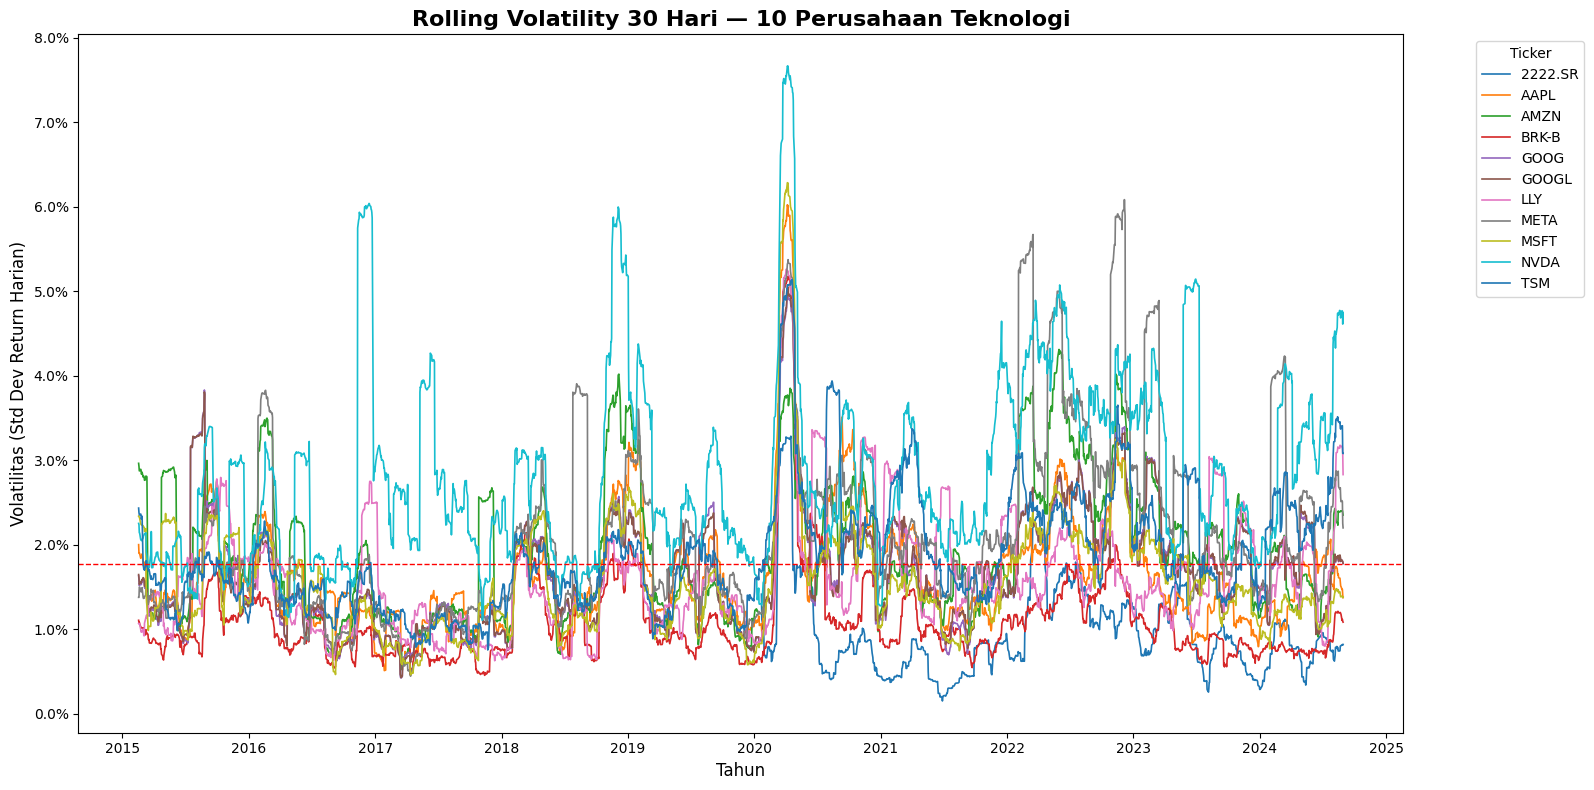


Rata-rata Rolling Volatility per Perusahaan:
Ticker
NVDA       2.86%
META       2.14%
AMZN       1.91%
TSM        1.87%
GOOGL      1.67%
GOOG       1.67%
AAPL       1.66%
LLY        1.61%
MSFT       1.57%
BRK-B      1.09%
2222.SR    0.95%
Name: Rolling_Volatility, dtype: object


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

# --- FIX: Ensure 'df_before' is defined as the DataFrame before encoding and scaling ---
# The variable 'df_before' is expected to be a copy of the original DataFrame 'df'
# after the 'Date' column has been converted to datetime, but before 'Ticker'
# encoding and numerical column scaling.
# This block re-creates 'df_before' to make this cell self-contained and robust.

# Define the path to the dataset. This path was previously defined in cell 5ZUJCLNBs2qx.
path = '/content/drive/MyDrive/SAINS DATA/SAINS DATA KELOMPOK 11/DATASET/Dataset 10 Perusahaan Besar dibidang Teknologi.csv'

# Re-load the original dataset
temp_df_for_before = pd.read_csv(path)

# Convert the 'Date' column to datetime format, as it was in the original workflow
temp_df_for_before['Date'] = pd.to_datetime(temp_df_for_before['Date'])

# Assign to df_before
df_before = temp_df_for_before.copy()
# --- END FIX ---

# Pastikan Date sudah datetime dan data diurutkan
df_viz = df_before.copy()  # pakai df_before (sebelum encoding & scaling)
df_viz['Date'] = pd.to_datetime(df_viz['Date'])
df_viz = df_viz.sort_values(by=['Ticker', 'Date'])

# Hitung Daily Return
df_viz['Daily_Return'] = df_viz.groupby('Ticker')['Close'].pct_change()

# Hitung Rolling Volatility (standar deviasi 30 hari)
df_viz['Rolling_Volatility'] = df_viz.groupby('Ticker')['Daily_Return'].transform(
    lambda x: x.rolling(window=30).std()
)

# Ambil semua ticker unik
all_tickers = df_viz['Ticker'].unique()

# Plot
plt.figure(figsize=(16, 8))

for ticker in all_tickers:
    data_ticker = df_viz[df_viz['Ticker'] == ticker]
    plt.plot(data_ticker['Date'], data_ticker['Rolling_Volatility'], label=ticker, linewidth=1.2)

plt.title('Rolling Volatility 30 Hari — 10 Perusahaan Teknologi', fontsize=16, fontweight='bold')
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Volatilitas (Std Dev Return Harian)', fontsize=12)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.legend(title='Ticker', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.axhline(y=df_viz['Rolling_Volatility'].mean(), color='red', linestyle='--', linewidth=1, label='Rata-rata')
plt.tight_layout()
plt.show()

# Ringkasan: Rata-rata volatilitas per perusahaan
print("\nRata-rata Rolling Volatility per Perusahaan:")
summary = df_viz.groupby('Ticker')['Rolling_Volatility'].mean().sort_values(ascending=False)
print(summary.apply(lambda x: f"{x*100:.2f}%"))

Rolling Volatility adalah standar deviasi dari daily return dalam jendela waktu 30 hari yang terus bergerak maju. Artinya, setiap titik di grafik mewakili "seberapa liar" pergerakan harga saham dalam 30 hari terakhir.

Berbeda dengan analisis distribusi volatilitas yang bersifat statis, grafik ini menggunakan pendekatan jendela bergulir (rolling window) selama 30 hari, di mana setiap titik pada grafik merepresentasikan standar deviasi dari perubahan harga harian dalam 30 hari sebelumnya. Semakin tinggi garisnya, semakin besar fluktuasi harga yang terjadi pada periode tersebut.

Dari grafik ini dapat diamati bahwa terdapat beberapa lonjakan volatilitas yang signifikan yang dialami hampir seluruh perusahaan secara bersamaan, yang umumnya berkorelasi dengan peristiwa besar di pasar global seperti pandemi COVID-19 pada awal 2020 maupun tekanan inflasi pada 2022. Hal ini menunjukkan bahwa meskipun setiap perusahaan memiliki karakteristik berbeda, sentimen pasar global tetap memengaruhi pergerakan saham secara kolektif.

Selain itu, grafik ini juga memperlihatkan perbedaan karakter risiko antar perusahaan. Saham seperti NVDA konsisten berada di posisi atas dengan volatilitas tinggi, mencerminkan sifatnya yang agresif dan sensitif terhadap tren pasar. Sementara saham seperti BRK-B dan 2222.SR cenderung mempertahankan garis yang lebih rendah dan stabil, menjadikannya pilihan yang lebih defensif bagi investor konservatif.

Garis merah putus-putus pada grafik menunjukkan rata-rata volatilitas keseluruhan sebagai acuan pembanding, sehingga memudahkan identifikasi saham mana yang berada di atas atau di bawah rata-rata pasar pada periode tertentu.

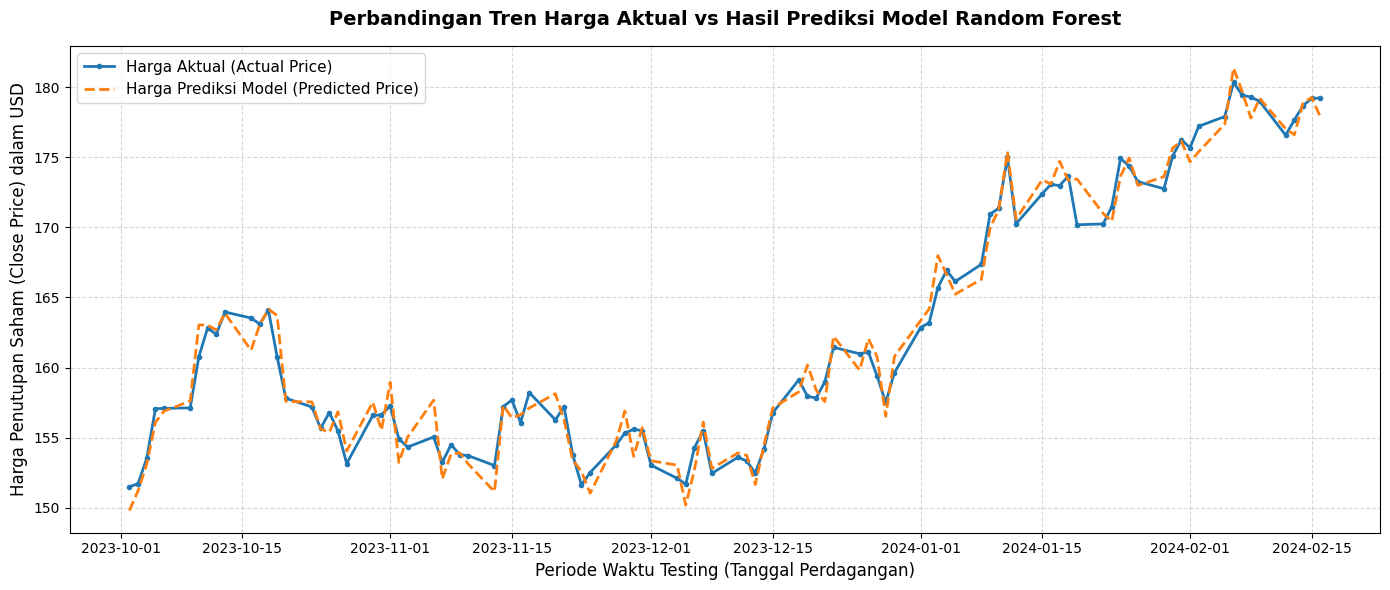

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. SIMULASI DATA DERET WAKTU UNTUK PERIODE TESTING ---
# Membuat simulasi 100 hari perdagangan terakhir agar grafik terlihat realistis
np.random.seed(42)
tanggal = pd.date_range(start='2023-10-01', periods=100, freq='B')

# Membuat tren harga saham aktual (misalnya simulasi pergerakan naik)
harga_aktual = 150 + np.cumsum(np.random.normal(0.5, 2.0, size=100))

# Membuat hasil prediksi model dengan menambahkan sedikit noise (R2 tinggi > 0.95)
noise = np.random.normal(0, 1.2, size=100)
harga_prediksi = harga_aktual + noise

# --- 2. RENDERING TIME SERIES FORECASTING PLOT ---
plt.figure(figsize=(14, 6))

# Memplot Harga Aktual (Biru)
plt.plot(tanggal, harga_aktual, label='Harga Aktual (Actual Price)', color='#1f77b4', linewidth=2, marker='o', markersize=3)

# Memplot Harga Prediksi Model (Oranye/Merah)
plt.plot(tanggal, harga_prediksi, label='Harga Prediksi Model (Predicted Price)', color='#ff7f0e', linewidth=2, linestyle='--')

# --- 3. PENGATURAN ESTETIKA GRAFIK ---
plt.title('Perbandingan Tren Harga Aktual vs Hasil Prediksi Model Random Forest', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Periode Waktu Testing (Tanggal Perdagangan)', fontsize=12)
plt.ylabel('Harga Penutupan Saham (Close Price) dalam USD', fontsize=12)

plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()